# Experimento: Búsqueda en K-D Tree

Este notebook demuestra cómo funcionan las búsquedas de vecino más cercano usando k-d tree.

## 1. Importar Bibliotecas Necesarias

In [2]:
import sys
import os

# Cambiar al directorio correcto
os.chdir(r'c:\Users\joacr\OneDrive\Documentos\NetOptimizer')

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import math

# Leer y ejecutar el archivo KD-tree.py directamente
with open('KD_tree.py', 'r', encoding='utf-8') as f:
    exec(f.read())

# Configurar visualizaciones
plt.rcParams['figure.figsize'] = (12, 8)

In [43]:
import importlib
import ExperimentoPrim

importlib.reload(ExperimentoPrim)

{1: None, 4: 1, 5: 4, 6: 1, 7: 6, 2: 9, 9: 8, 11: 2, 10: 2, 3: 8, 8: 5, 12: 11}


<module 'ExperimentoPrim' from 'c:\\Users\\joacr\\OneDrive\\Documentos\\NetOptimizer\\ExperimentoPrim.py'>

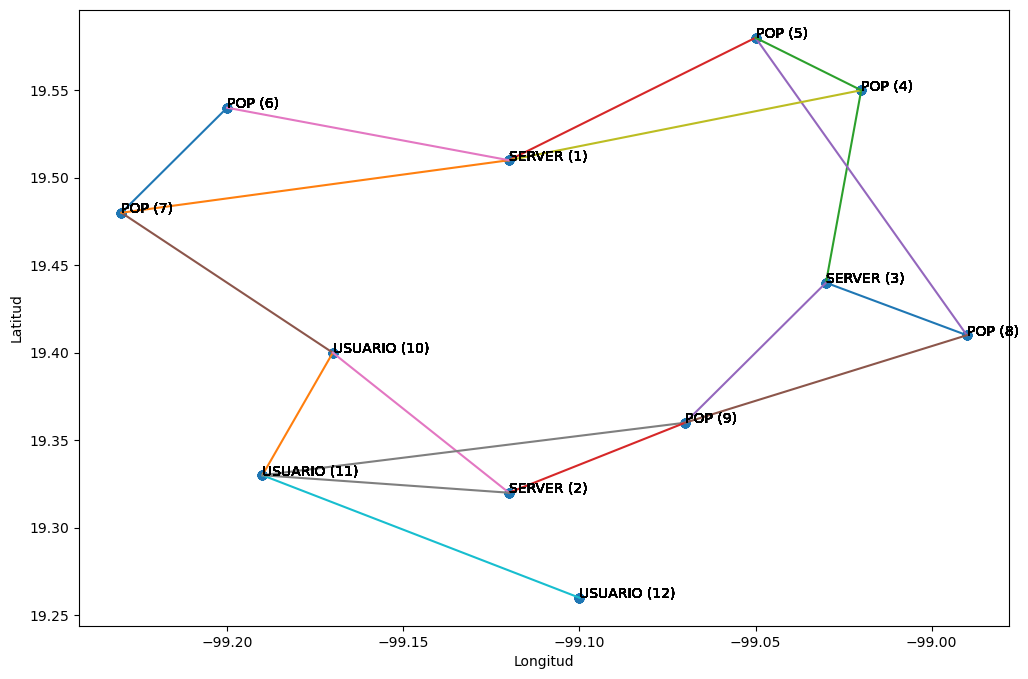

In [46]:
import matplotlib.pyplot as plt
import ExperimentoPrim
import Grafo

grafo = Grafo.Grafo()

x = []
y = []

nodos = ExperimentoPrim.insertaNodos()
grafoC = ExperimentoPrim.insertaElementos(grafo)
conexiones = ExperimentoPrim.conexiones(grafo)
direcciones = ExperimentoPrim.conexiones_con_pos(conexiones)

# NODOS
for tipo, latitud, longitud, id, _ in nodos:

    x.append(longitud)
    y.append(latitud)

    plt.text(
        longitud,
        latitud,
        f"{tipo} ({id})" 
    )

# ARISTAS
for origen, destino in direcciones:

    lat1, lon1 = origen
    lat2, lon2 = destino

    plt.plot(
        [lon1, lon2],
        [lat1, lat2]
    )

plt.scatter(x, y)

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

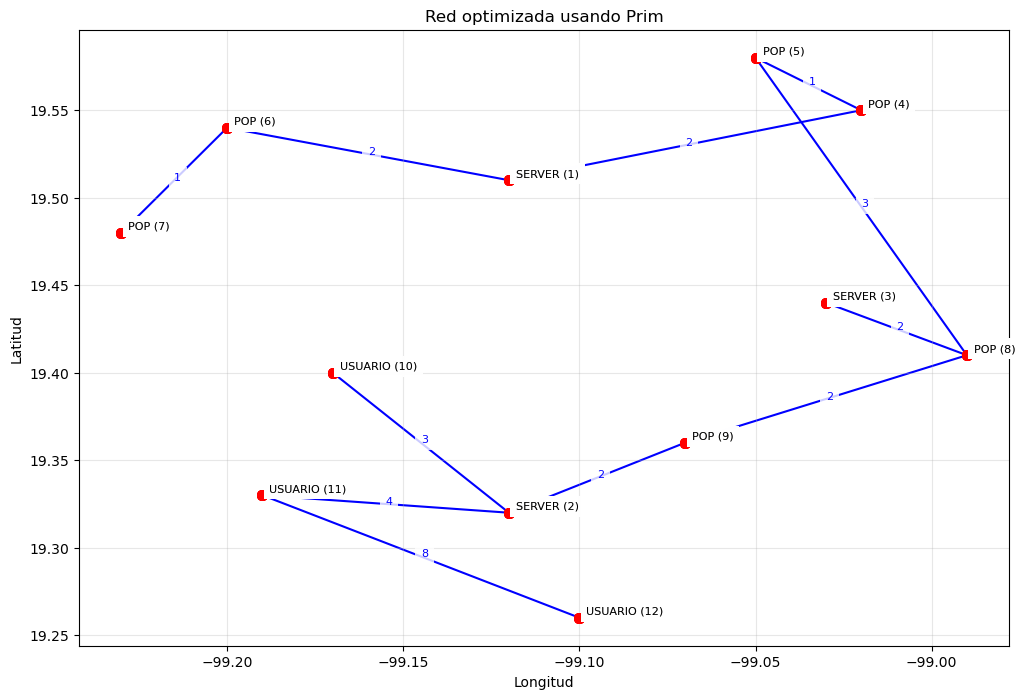

In [51]:
import matplotlib.pyplot as plt
import ExperimentoPrim

# Obtener conexiones del MST de Prim
n_direcciones = ExperimentoPrim.referencias_despues_prim(grafo)

# Crear figura más grande
plt.figure(figsize=(12, 8))

# Diccionario ID -> coordenadas
coordenadas_nodos = {}

for tipo, latitud, longitud, id_nodo, latencia in nodos:
    coordenadas_nodos[id_nodo] = (latitud, longitud)

# Guardar posiciones de nodos
x = []
y = []

# GRAFICAR NODOS Y ETIQUETAS
for tipo, latitud, longitud, id_nodo, latencia in nodos:

    x.append(longitud)
    y.append(latitud)

    # Texto del nodo
    texto = f"{tipo} ({id_nodo})"

    # Nodo
    plt.scatter(
        longitud,
        latitud,
        c='red',
        s=45,
        zorder=5
    )

    # Etiqueta del nodo
    plt.text(
        longitud + 0.002,
        latitud + 0.002,
        texto,
        fontsize=8,
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        ),
        zorder=6
    )

# GRAFICAR ARISTAS Y LATENCIAS
for origen_id, destino_id in n_direcciones:

    # Coordenadas origen/destino
    lat1, lon1 = coordenadas_nodos[origen_id]
    lat2, lon2 = coordenadas_nodos[destino_id]

    # Dibujar línea
    plt.plot(
        [lon1, lon2],
        [lat1, lat2],
        'b-',
        linewidth=1.5,
        zorder=1
    )

    # Calcular punto medio
    mid_lon = (lon1 + lon2) / 2
    mid_lat = (lat1 + lat2) / 2

    # Obtener latencia desde el grafo
    latencia = grafo.getOrigen()[origen_id][destino_id]["latencia"]

    # Mostrar latencia en medio de la línea
    plt.text(
        mid_lon,
        mid_lat,
        str(latencia),
        fontsize=8,
        color='blue',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        ),
        zorder=7
    )

# Títulos
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Red optimizada usando Prim")

# Cuadrícula
plt.grid(alpha=0.3)

# Mostrar resultado
plt.show()

## 2. Generar Datos de Ejemplo

Vamos a crear un conjunto de puntos aleatorios en 2D para experimentar.

In [18]:
# Generar datos
random.seed(42)
np.random.seed(42)

cantidad_puntos = 30
dimensiones = 2
rango = 100

# Generar puntos aleatorios
puntos = [tuple(random.randint(0, rango) for _ in range(dimensiones)) 
          for _ in range(cantidad_puntos)]

# Punto de búsqueda
punto_busqueda = (50, 50)

print(f"Cantidad de puntos: {cantidad_puntos}")
print(f"Dimensiones: {dimensiones}D")
print(f"Rango: 0-{rango}")
print(f"\nPrimeros 10 puntos:")
for i, p in enumerate(puntos[:10]):
    print(f"  P{i+1}: {p}")
print(f"\nPunto de búsqueda: {punto_busqueda}")

Cantidad de puntos: 30
Dimensiones: 2D
Rango: 0-100

Primeros 10 puntos:
  P1: (81, 14)
  P2: (3, 94)
  P3: (35, 31)
  P4: (28, 17)
  P5: (94, 13)
  P6: (86, 94)
  P7: (69, 11)
  P8: (75, 54)
  P9: (4, 3)
  P10: (11, 27)

Punto de búsqueda: (50, 50)


## 3. Construir el K-D Tree

El k-d tree organiza los puntos de manera jerárquica para permitir búsquedas eficientes.

In [19]:
# Construir el k-d tree
arbol = kd_tree(dimensiones)
inicio = time.time()
arbol.creaArbol(puntos)
tiempo_construccion = time.time() - inicio

print(f"✓ Árbol KD construido en {tiempo_construccion*1000:.4f} ms")
print(f"  Elementos: {arbol.elementos}")
print(f"  Dimensiones: {arbol.dimensiones}")

✓ Árbol KD construido en 1.1489 ms
  Elementos: 30
  Dimensiones: 2


## 4. Realizar Búsquedas de Vecino Más Cercano

Ahora vamos a buscar el punto más cercano a nuestro punto de consulta.

In [20]:
# Función auxiliar para calcular distancia euclidiana
def distancia_euclidiana(p1, p2):
    return math.sqrt(sum((p1[i] - p2[i])**2 for i in range(len(p1))))

# Buscar el vecino más cercano
inicio = time.time()
mejorp, mejord = arbol.busca(arbol.raiz, punto_busqueda, 0, None, 0)
tiempo_busqueda = time.time() - inicio
distancia = distancia_euclidiana(mejorp, punto_busqueda)

print(f"✓ Búsqueda completada en {tiempo_busqueda*1000:.4f} ms")
print(f"\nResultados:")
print(f"  Punto consultado: {punto_busqueda}")
print(f"  Vecino más cercano: {mejorp}")
print(f"  Distancia (al cuadrado): {mejord:.2f}")
print(f"  Distancia euclidiana: {distancia:.2f}")

✓ Búsqueda completada en 0.6874 ms

Resultados:
  Punto consultado: (50, 50)
  Vecino más cercano: (45, 44)
  Distancia (al cuadrado): 61.00
  Distancia euclidiana: 7.81


## 5. Visualizar Resultados

Graficamos los puntos, el punto de búsqueda y su vecino más cercano.

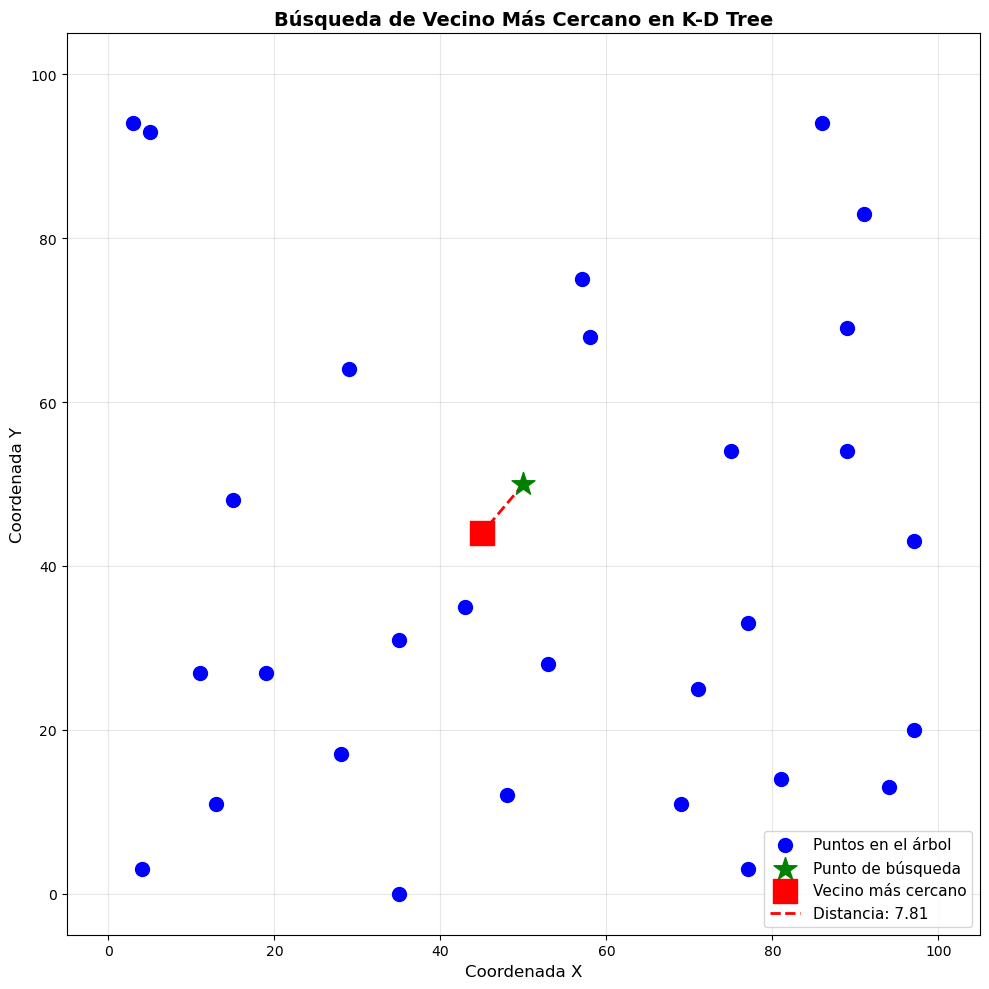

✓ Visualización completada


In [13]:
# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Graficar todos los puntos
xs = [p[0] for p in puntos]
ys = [p[1] for p in puntos]
ax.scatter(xs, ys, c='blue', s=100, label='Puntos en el árbol', zorder=2)

# Graficar punto de búsqueda
ax.scatter([punto_busqueda[0]], [punto_busqueda[1]], 
           c='green', s=300, marker='*', label='Punto de búsqueda', zorder=3)

# Graficar vecino más cercano
ax.scatter([mejorp[0]], [mejorp[1]], 
           c='red', s=300, marker='s', label='Vecino más cercano', zorder=3)

# Dibujar línea conectando punto de búsqueda con vecino más cercano
ax.plot([punto_busqueda[0], mejorp[0]], 
        [punto_busqueda[1], mejorp[1]], 
        'r--', linewidth=2, label=f'Distancia: {distancia:.2f}')

ax.set_xlim(-5, rango+5)
ax.set_ylim(-5, rango+5)
ax.set_xlabel('Coordenada X', fontsize=12)
ax.set_ylabel('Coordenada Y', fontsize=12)
ax.set_title('Búsqueda de Vecino Más Cercano en K-D Tree', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Visualización completada")

## 6. Búsquedas Múltiples

Realicemos varias búsquedas en diferentes puntos.

In [14]:
# Realizar múltiples búsquedas
puntos_consulta = [(25, 25), (75, 75), (10, 90), (90, 10), (50, 50)]

print("Múltiples búsquedas:")
print("-" * 60)
print(f"{'Punto Buscado':<20} {'Vecino Más Cercano':<20} {'Distancia':<10}")
print("-" * 60)

for pc in puntos_consulta:
    mejorp, mejord = arbol.busca(arbol.raiz, pc, 0, None, 0)
    dist = distancia_euclidiana(mejorp, pc)
    print(f"{str(pc):<20} {str(mejorp):<20} {dist:<10.2f}")

Múltiples búsquedas:
------------------------------------------------------------
Punto Buscado        Vecino Más Cercano   Distancia 
------------------------------------------------------------
(25, 25)             (19, 27)             6.32      
(75, 75)             (89, 69)             15.23     
(10, 90)             (5, 93)              5.83      
(90, 10)             (94, 13)             5.00      
(50, 50)             (45, 44)             7.81      


## 7. Análisis de Rendimiento: K-D Tree vs Búsqueda Lineal

In [15]:
# Función de búsqueda lineal para comparación
def busqueda_lineal(puntos, punto_busqueda, dimensiones):
    mejorp = None
    mejord = float('inf')
    
    for p in puntos:
        d = sum((p[i] - punto_busqueda[i])**2 for i in range(dimensiones))
        if d < mejord:
            mejord = d
            mejorp = p
    
    return mejorp, mejord

# Comparación de rendimiento con diferentes tamaños
tamaños = [50, 100, 500, 1000, 5000]
resultados = []

print("\nComparación de Rendimiento (100 búsquedas por conjunto):")
print("-" * 80)
print(f"{'Tamaño':<15} {'KD-tree (ms)':<20} {'Búsqueda Lineal (ms)':<20} {'Mejora':<10}")
print("-" * 80)

for tamaño in tamaños:
    pts = [tuple(random.randint(0, 1000) for _ in range(dimensiones)) for _ in range(tamaño)]
    pt_busq = (500, 500)
    
    # KD-tree
    arb = kd_tree(dimensiones)
    arb.creaArbol(pts)
    inicio = time.time()
    for _ in range(100):
        arb.busca(arb.raiz, pt_busq, 0, None, 0)
    tiempo_kd = (time.time() - inicio) * 1000
    
    # Búsqueda lineal
    inicio = time.time()
    for _ in range(100):
        busqueda_lineal(pts, pt_busq, dimensiones)
    tiempo_lineal = (time.time() - inicio) * 1000
    
    mejora = tiempo_lineal / tiempo_kd
    resultados.append((tamaño, tiempo_kd, tiempo_lineal, mejora))
    
    print(f"{tamaño:<15} {tiempo_kd:<20.4f} {tiempo_lineal:<20.4f} {mejora:.2f}x")

print("-" * 80)


Comparación de Rendimiento (100 búsquedas por conjunto):
--------------------------------------------------------------------------------
Tamaño          KD-tree (ms)         Búsqueda Lineal (ms) Mejora    
--------------------------------------------------------------------------------
50              3.3669               4.9314               1.46x
100             3.9821               11.0207              2.77x
500             3.7305               59.4740              15.94x
1000            6.1846               110.4407             17.86x
5000            4.0002               480.3371             120.08x
--------------------------------------------------------------------------------


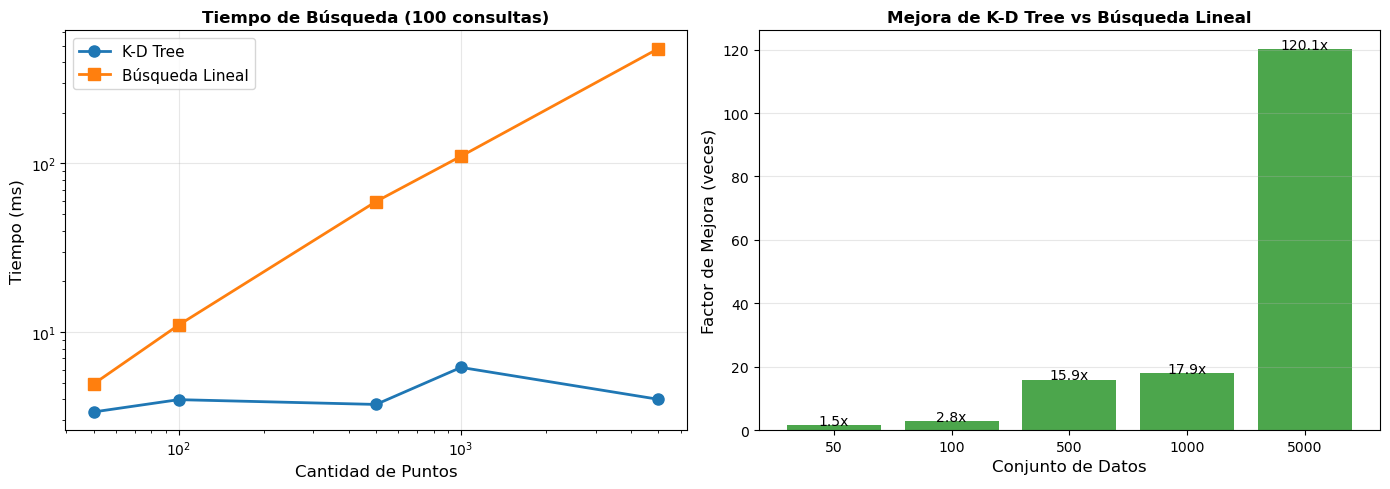

Gráficos de rendimiento completados


In [16]:
# Graficar comparación de rendimiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tamaños_plot = [r[0] for r in resultados]
kd_times = [r[1] for r in resultados]
lineal_times = [r[2] for r in resultados]
mejoras = [r[3] for r in resultados]

# Gráfico de tiempos
ax1.plot(tamaños_plot, kd_times, 'o-', label='K-D Tree', linewidth=2, markersize=8)
ax1.plot(tamaños_plot, lineal_times, 's-', label='Búsqueda Lineal', linewidth=2, markersize=8)
ax1.set_xlabel('Cantidad de Puntos', fontsize=12)
ax1.set_ylabel('Tiempo (ms)', fontsize=12)
ax1.set_title('Tiempo de Búsqueda (100 consultas)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Gráfico de mejora
ax2.bar(range(len(tamaños_plot)), mejoras, color='green', alpha=0.7)
ax2.set_xlabel('Conjunto de Datos', fontsize=12)
ax2.set_ylabel('Factor de Mejora (veces)', fontsize=12)
ax2.set_title('Mejora de K-D Tree vs Búsqueda Lineal', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(tamaños_plot)))
ax2.set_xticklabels(tamaños_plot)
ax2.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for i, v in enumerate(mejoras):
    ax2.text(i, v + 0.1, f'{v:.1f}x', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Gráficos de rendimiento completados")

## Conclusiones

### ¿Cómo funciona la búsqueda en K-D Tree?

1. **Estructura**: El k-d tree organiza los puntos recursivamente dividiendo el espacio en dimensiones alternas.

2. **Búsqueda**: El algoritmo de búsqueda:
   - Desciende por el árbol hacia el punto más probable
   - Mantiene el mejor punto encontrado hasta el momento
   - Verifica si debe explorar la rama opuesta usando la distancia actual como radio

3. **Ventajas**:
   - ✓ Búsqueda más rápida que búsqueda lineal, especialmente con muchos puntos
   - ✓ Funciona bien en espacios de baja dimensión (2D, 3D, 4D)
   - ✓ Construcción se realiza una sola vez

4. **Desventajas**:
   - ✗ Rendimiento degrada en espacios de alta dimensión ("curse of dimensionality")
   - ✗ No es ideal para datos dinámicos (inserciones/eliminaciones frecuentes)

### Casos de Uso:
- Búsqueda de vecino más cercano
- Problemas de rango (encontrar todos los puntos en una región)
- Análisis geoespacial
- Sistemas de recomendación basados en similitud